In [2]:
import cooler
import cooltools
import bioframe as bf
import bbi
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ggner_3d.cm import CLR_CONNS, get_expected_cis_df, prepare_view_df
from ggner_3d.boundaries import preserved_boundaries_only, make_tads, assign_domain_score, get_insulation_fixed
from ggner_3d.dots_common import compare_loops_with_strength
from ggner_3d.bbi_helpers import stackup_bw_dict, stackup_bw_dict_q


NPROC = 8
resolution = 10000
window = 500_000

# tad lengths
MAXLEN = 2e6
MINLEN = 2.5e5

rescale_flank = 1
rescale_size = 33 * (2 * rescale_flank + 1)
assert rescale_size % (2 * rescale_flank + 1) == 0 and rescale_size % 2 == 1, "rescale_size"
score_flank=rescale_flank

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
pol2_dict = {
    'noUV': [
        '/home/carlos/Clone/ggner-3d/data/imr90/GSM5206904_Rep1_Untreated-RPB1ChIP-R2.spikeIn.seqDepth.bw',
        '/home/carlos/Clone/ggner-3d/data/imr90/GSM5206907_Rep2_MRC5_0J_75min_RPB1ChIP.spikeIn.seqDepth.bw',
    ],
    'postUV': [
        '/home/carlos/Clone/ggner-3d/data/imr90/GSM5206903_Rep1_4j-75min-RPB1ChIP-R2.spikeIn.seqDepth.bw',
        '/home/carlos/Clone/ggner-3d/data/imr90/GSM5206909_Rep2_MRC5_4J_75min_RPB1ChIP.spikeIn.seqDepth.bw']
}

In [4]:
clr = cooler.Cooler('/home/carlos/Clone/ggner-3d/data/imr90/4DNFIJTOIGOI.mcool::/resolutions/10000')

In [5]:
# insulation_df = cooltools.insulation(
#             clr = clr,
#             window_bp = [500_000],
#             clr_weight_name='weight',
#             nproc=NPROC
#         )
# insulation_df.to_csv('/home/carlos/Clone/ggner-3d/data/imr90/imr90_insulation_500k.csv', index=False)


In [6]:
insulation_df = pd.read_csv('/home/carlos/Clone/ggner-3d/data/imr90/imr90_insulation_500k.csv')

In [7]:
# expected_df = cooltools.expected_cis(
#     clr=clr,
#     clr_weight_name='weight',
#     nproc=NPROC
# )
# expected_df.to_csv('/home/carlos/Clone/ggner-3d/data/imr90/imr90_expected_cis.csv', index=False)


In [8]:
expected_df = pd.read_csv('/home/carlos/Clone/ggner-3d/data/imr90/imr90_expected_cis.csv')

In [9]:
boundaries = insulation_df[insulation_df['is_boundary_500000'] == True].copy()
tads = make_tads(boundaries, maxlen=MAXLEN, minlen=MINLEN)


In [10]:
view_df = prepare_view_df(arm=False)
ds = assign_domain_score(
    clr = clr,
    expected = expected_df,
    view_df=view_df,
    tads_df=tads,
    nproc=NPROC,
    clr_weight_name='weight',
    rescale_flank=rescale_flank,
    rescale_size=rescale_size,
    score_flank=score_flank,
)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr7', 'chr7'): 150
INFO:coolpuppy:('chr8', 'chr8'): 134
INFO:coolpuppy:('chr5', 'chr5'): 171
INFO:coolpuppy:('chr6', 'chr6'): 179
INFO:coolpuppy:('chr4', 'chr4'): 176
INFO:coolpuppy:('chr3', 'chr3'): 195
INFO:coolpuppy:('chr1', 'chr1'): 256
INFO:coolpuppy:('chr2', 'chr2'): 235
INFO:coolpuppy:('chr9', 'chr9'): 114
INFO:coolpuppy:('chr10', 'chr10'): 125
INFO:coolpuppy:('chr13', 'chr13'): 94
INFO:coolpuppy:('chr14', 'chr14'): 94
INFO:coolpuppy:('chr11', 'chr11'): 143
INFO:coolpuppy:('chr12', 'chr12'): 149
INFO:coolpuppy:('chr16', 'chr16'): 73
INFO:coolpuppy:('chr15', 'chr15'): 93
INFO:coolpuppy:('chr17', 'chr17'): 99
INFO:coolpuppy:('chr21', 'chr21'): 33
INFO:coolpuppy:('chr19', 'chr19'): 69
INFO:coolpuppy:('chr22', 'chr22'): 41
INFO:coolpuppy:('chr18', 'chr18'): 65
INFO:coolpuppy:('chr20', 'chr20'): 68
INFO:coolpuppy:('chrX', 'chrX'): 84
INFO:coolpuppy:Total number of piled up windows: 256


In [11]:
ds['Q'] = pd.qcut(ds['domain_score'], 4, labels=False) + 1

In [12]:
# tads = pd.read_csv('/home/carlos/Clone/ggner-3d/data/imr90/GSM4662834.tad.hg38.bed', sep='\t', header=None).iloc[:, :3]
# tads.columns = ['chrom', 'start', 'end']
# tads

In [21]:
flank_ratio = 0.25

ds_df = ds.copy()

ds_df['flank_start'] = ds_df['start'] - (ds_df['end'] - ds_df['start']) * flank_ratio
ds_df['flank_end'] = ds_df['end'] + (ds_df['end'] - ds_df['start']) * flank_ratio

# drop chr prefix
ds_df['chrom'] = ds_df['chrom'].str.replace('chr', '')

# only 1-22 + X
ds_df = ds_df[ds_df['chrom'].isin([str(i) for i in range(1, 23)] + ['X'])]

nbins = 150
mean_per_q=False
preuv_stacks = stackup_bw_dict_q(
    bw_list= pol2_dict['noUV'],
    df=ds_df,
    nbins=nbins,
    mean_per_q=mean_per_q
)

postuv_stacks = stackup_bw_dict_q(
    bw_list= pol2_dict['postUV'],
    df=ds_df,
    nbins=nbins,
    mean_per_q=mean_per_q
)

delta = {q: postuv_stacks[q] - preuv_stacks[q] for q in preuv_stacks.keys()}

In [22]:
from ggner_3d import plotting
from ggner_3d.plotting import plot_flanks_start_end_stackup, lineplot_stackup_dict
plotting.update_rcparams()

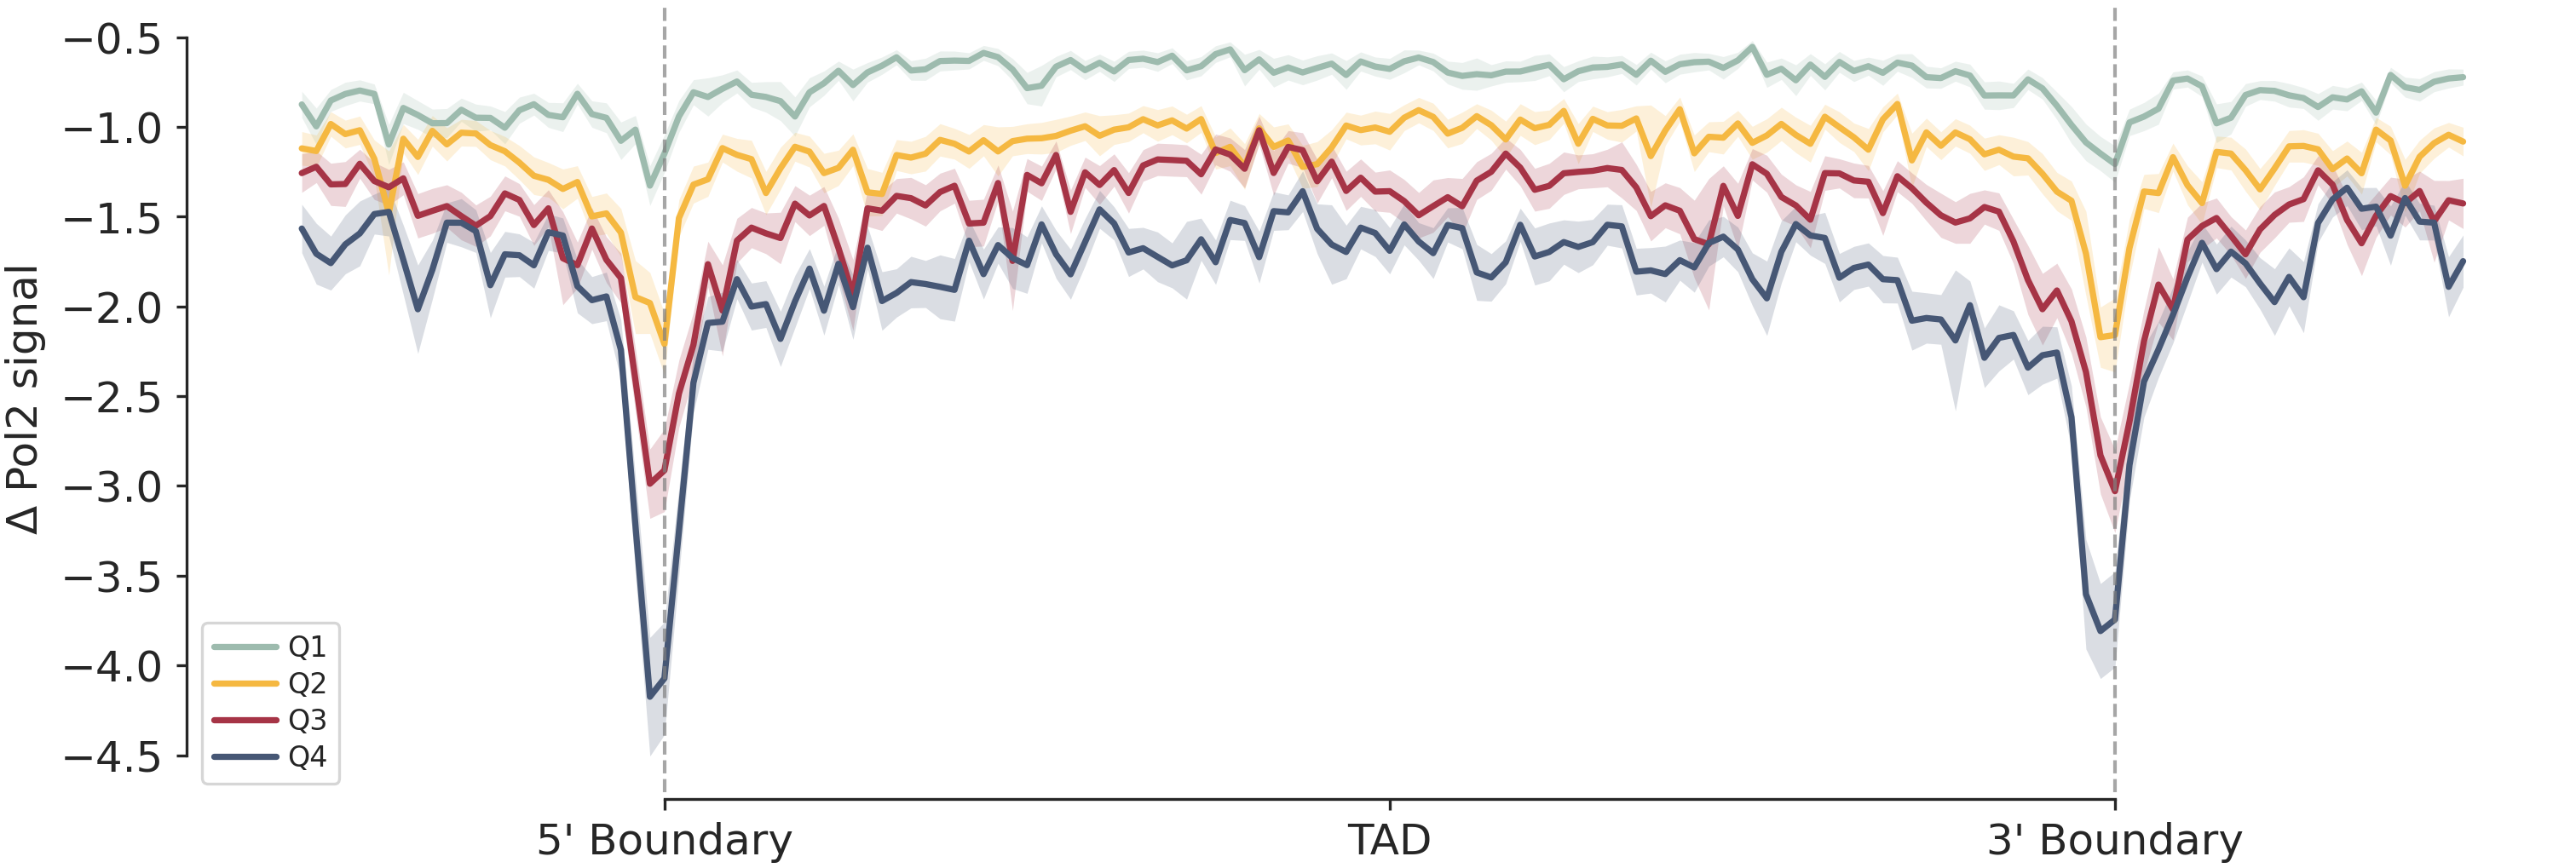

In [25]:
from ggner_3d import plotting

colors = list(reversed(plotting.COLORS))
fig, ax = plt.subplots(1, 1, figsize=(12, 4), sharex='col')

common_params = {
    'plot_kwargs': {'linewidth': 1.75},
    'colors': list(reversed(plotting.COLORS))
}

lineplot_stackup_dict(
    delta,
    ax=ax,
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='',
    y_title='Δ Pol2 signal',
    structure_type='TAD',
    **common_params
)

# make all tick labels bigger
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

plotting.despine(ax)

fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig5/imr90_pol2_signal_by_q.svg', bbox_inches='tight')